# Проект: классификация

In [72]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from  sklearn.ensemble import IsolationForest
import warnings
warnings.filterwarnings('ignore')
from sklearn.preprocessing  import LabelEncoder
from sklearn import linear_model 
from sklearn import tree 
from sklearn import ensemble 
from sklearn import metrics 
from sklearn import preprocessing 
from sklearn.model_selection import train_test_split 
from sklearn.feature_selection import SelectKBest, f_classif
from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import f1_score

In [3]:
!pip install -U pip
!pip install "pandas>=2.2" "numpy>=2.0" "scikit-learn>=1.5"

   ---------------------------------------- 0.0/1.8 MB ? eta -:--:--
   ---------------------------------------- 0.0/1.8 MB ? eta -:--:--
   ----- ---------------------------------- 0.3/1.8 MB ? eta -:--:--
   ----------- ---------------------------- 0.5/1.8 MB 1.4 MB/s eta 0:00:01
   ----------------- ---------------------- 0.8/1.8 MB 1.3 MB/s eta 0:00:01
   ----------------------- ---------------- 1.0/1.8 MB 1.3 MB/s eta 0:00:01
   ----------------------------- ---------- 1.3/1.8 MB 1.2 MB/s eta 0:00:01
   ----------------------------------- ---- 1.6/1.8 MB 1.2 MB/s eta 0:00:01
   ----------------------------------- ---- 1.6/1.8 MB 1.2 MB/s eta 0:00:01
   ---------------------------------------- 1.8/1.8 MB 969.5 kB/s eta 0:00:00



[notice] A new release of pip is available: 25.1.1 -> 25.3
[notice] To update, run: python.exe -m pip install --upgrade pip
ERROR: To modify pip, please run the following command:
C:\Users\arinathebest\AppData\Local\Programs\Python\Python313\python.exe -m pip install -U pip



[notice] A new release of pip is available: 25.1.1 -> 25.3
[notice] To update, run: python.exe -m pip install --upgrade pip


Данные о клиентах банка:

age (возраст);

job (сфера занятости);

marital (семейное положение);

education (уровень образования);

default (имеется ли просроченный кредит);

housing (имеется ли кредит на жильё);

loan (имеется ли кредит на личные нужды);

balance (баланс).

Данные, связанные с последним контактом в контексте текущей маркетинговой кампании:

contact (тип контакта с клиентом);

month (месяц, в котором был последний контакт);

day (день, в который был последний контакт);

duration (продолжительность контакта в секундах).

Прочие признаки:

campaign (количество контактов с этим клиентом в течение текущей кампании);

pdays (количество пропущенных дней с момента последней маркетинговой кампании до контакта в текущей кампании);

previous (количество контактов до текущей кампании)

poutcome (результат прошлой маркетинговой кампании).

И, разумеется, наша целевая переменная deposit, которая определяет, согласится ли клиент открыть депозит в банке. Именно её мы будем пытаться предсказать в данном кейсе.

## Часть 1. Знакомство с данными, обработка пропусков и выбросов

### Задание 1

In [4]:
df = pd.read_csv(r'C:\Users\arinathebest\Desktop\CSV_skillfactory\projects\p-3\bank_fin.csv', sep = ';')

In [5]:
# исследуйте данные на предмет пропусков. Где есть пропущенные значения? Сколько их?
# ваш код
df.isna().sum()

age           0
job           0
marital       0
education     0
default       0
balance      25
housing       0
loan          0
contact       0
day           0
month         0
duration      0
campaign      0
pdays         0
previous      0
poutcome      0
deposit       0
dtype: int64

### Задание 2

In [6]:
# есть ли в признаке job пропущенные значения? Возможно, они обозначены каким-то специальным словом?
# ваш код
df['job'].unique()

array(['admin.', 'technician', 'services', 'management', 'retired',
       'blue-collar', 'unemployed', 'entrepreneur', 'housemaid',
       'unknown', 'self-employed', 'student'], dtype=object)

### Задание 3

In [7]:
# преобразуйте признак balance таким образом, чтобы он корректно считывался, как вещественное число (float)
df['balance'] = df['balance'].str.replace('$','').str.replace(' ', '').str.replace(',','.').astype(float)
round(df['balance'].mean(),3)

np.float64(1529.129)

### Задание 4

In [8]:
# обработайте пропуски в признаки balance , заменив их на медианные значения по данному признаку
# ваш код
median_balance = df['balance'].median()
df['balance']=df['balance'].fillna(median_balance)
round(df['balance'].mean(),3)

np.float64(1526.936)

### Задание 5

In [9]:
# обработайте пропуски в категориальных признаках: job и education, заменив их на модальные значения
# ваш код
mode_education = df['education'].mode()[0]
mode_job = df['job'].mode()[0]
df['education']=df['education'].replace('unknown', np.nan)
df['job'] = df['job'].replace('unknown', np.nan)
df['education'] = df['education'].fillna(mode_education)
df['job'] = df['job'].fillna(mode_job)

In [10]:
df_job = df['job'].mode()[0]
df_edu = df['education'].mode()[0]
mask = (df['job']==df_job) & (df['education']==df_edu)
reslut = df.loc[mask,'balance'].mean()
print(reslut)

1598.8829787234042


### Задание 6

In [11]:
df['balance'].shape

(11162,)

In [12]:
# удалите все выбросы для признака balance
# ваш код
q1 = np.percentile(df['balance'],25)
q3 = np.percentile(df['balance'], 75)
iqr = q3-q1
lower_bound = q1-1.5*iqr
upper_bound = q3+1.5*iqr

df = df[(df['balance'] >= lower_bound) & (df['balance'] <= upper_bound)]
print((upper_bound, lower_bound))

(np.float64(4063.0), np.float64(-2241.0))


In [13]:
df['balance'].shape

(10105,)

## Часть 2:  Разведывательный анализ

### Задание 1

In [14]:
df[df['deposit']=='yes']

,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,deposit
0,59,admin.,married,secondary,no,2343.0,yes,no,unknown,5,may,1042,1,-1,0,unknown,yes
1,56,admin.,married,secondary,no,45.0,no,no,unknown,5,may,1467,1,-1,0,unknown,yes
2,41,technician,married,secondary,no,1270.0,yes,no,unknown,5,may,1389,1,-1,0,unknown,yes
3,55,services,married,secondary,no,2476.0,yes,no,unknown,5,may,579,1,-1,0,unknown,yes
4,54,admin.,married,tertiary,no,184.0,no,no,unknown,5,may,673,2,-1,0,unknown,yes
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5284,78,retired,divorced,primary,no,1389.0,no,no,cellular,8,apr,335,1,-1,0,unknown,yes
5285,30,management,single,tertiary,no,398.0,no,no,cellular,27,oct,102,1,180,3,success,yes
5286,69,retired,divorced,tertiary,no,247.0,no,no,cellular,22,apr,138,2,-1,0,unknown,yes
5287,48,entrepreneur,married,secondary,no,0.0,no,yes,cellular,28,jul,431,2,-1,0,unknown,yes


### Задания 2 и 3

In [15]:
#рассчитайте описательные статистики для количественных переменных, проинтерпретируйте результат
#ваш код
df.describe()

,age,balance,day,duration,campaign,pdays,previous
count,10105.000000,10105.000000,10105.000000,10105.000000,10105.000000,10105.000000,10105.000000
mean,40.895497,807.653538,15.590302,368.742603,2.517170,51.319644,0.816230
std,11.734931,994.151966,8.441510,346.651524,2.707159,109.644179,2.243795
min,18.000000,-2049.000000,1.000000,2.000000,1.000000,-1.000000,0.000000
25%,32.000000,95.000000,8.000000,137.000000,1.000000,-1.000000,0.000000
50%,38.000000,445.000000,15.000000,252.000000,2.000000,-1.000000,0.000000
75%,48.000000,1227.000000,22.000000,490.000000,3.000000,2.000000,1.000000
max,95.000000,4063.000000,31.000000,3881.000000,43.000000,854.000000,58.000000


### Задания 4 и 5

In [16]:
#рассчитайте описательные статистики для категориальных переменных, проинтерпретируйте результат
#ваш код
#постройте визуализации, иллюстрирующие результаты
df.describe(include='object')


,job,marital,education,default,housing,loan,contact,month,poutcome,deposit
count,10105,10105,10105,10105,10105,10105,10105,10105,10105,10105
unique,11,3,3,2,2,2,3,12,4,2
top,management,married,secondary,no,no,no,cellular,may,unknown,no
freq,2315,5715,5517,9939,5243,8712,7283,2617,7570,5424


Text(0.5, 1.0, 'Открыт ли депозит, у людей без/c кредитом на жилье ')

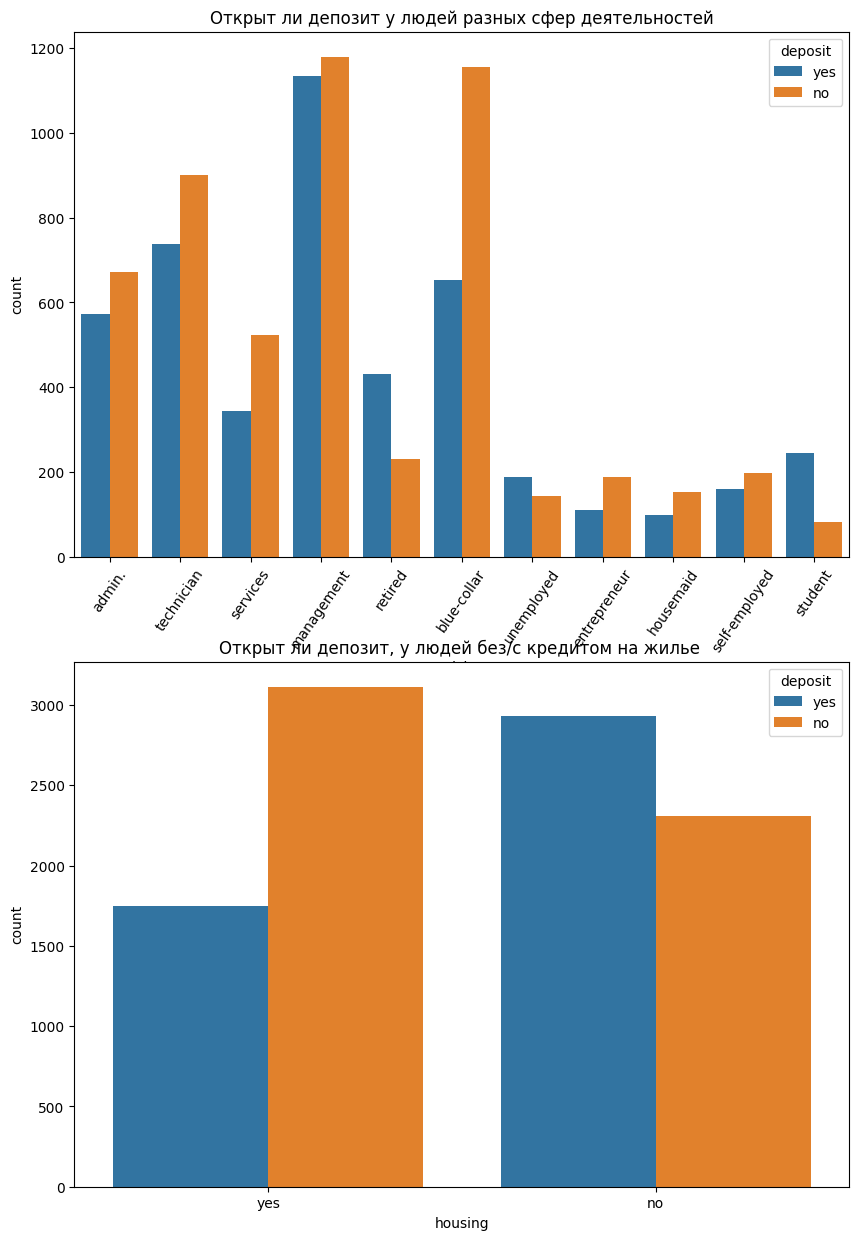

In [17]:
fig,axes = plt.subplots(2,1, figsize=(10,15))
sns.countplot(x='job', data=df, hue='deposit', ax=axes[0])
axes[0].tick_params(axis='x', rotation=55)
axes[0].set_title('Открыт ли депозит у людей разных сфер деятельностей')
sns.countplot(x='housing', hue='deposit', data=df,ax=axes[1])
axes[1].set_title('Открыт ли депозит, у людей без/c кредитом на жилье ')

### Задание 6

In [18]:
# Узнайте, для какого статуса предыдущей маркетинговой кампании успех в текущей превалирует над количеством неудач.
# ваш код
vc = df.groupby('poutcome')['deposit'].value_counts()
print(vc)

poutcome  deposit
failure   no          562
          yes         547
other     yes         265
          no          216
success   yes         861
          no           84
unknown   no         4562
          yes        3008
Name: count, dtype: int64


### Задание 7

<Axes: xlabel='month', ylabel='count'>

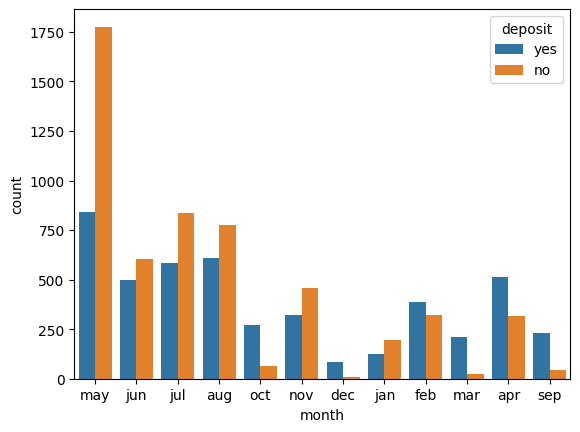

In [19]:
# узнайте, в каком месяце чаще всего отказывались от предложения открыть депозит
# ваш код
sns.countplot(x='month',hue='deposit',data=df)

### Задание 8

<Axes: xlabel='age', ylabel='count'>

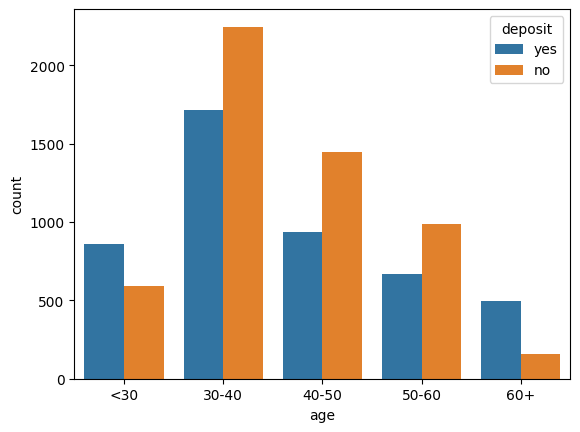

In [20]:
# создайте возрастные группы и определите, в каких группах более склонны открывать депозит, чем отказываться от предложения
bins = [0,30,40,50,60, float('inf')]
labels = ['<30', '30-40','40-50','50-60','60+']
df['age'] = pd.cut(df['age'],bins=bins,labels=labels,right=False)
sns.countplot(x='age',data=df, hue='deposit')

### Задания 9 и 10

In [21]:
df['marital']

0        married
1        married
2        married
3        married
4        married
          ...   
11157     single
11158    married
11159     single
11160    married
11161    married
Name: marital, Length: 10105, dtype: object

<Axes: xlabel='marital', ylabel='count'>

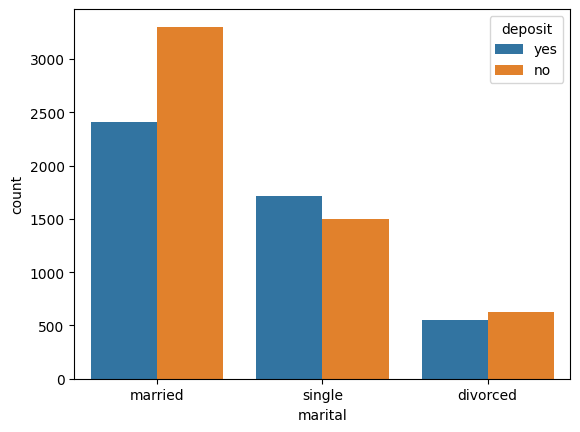

In [22]:
# постройте визуализации для открывших и неоткрывших депозит в зависимости от семейного статуса
sns.countplot(x='marital', data=df, hue='deposit')

<Axes: xlabel='education', ylabel='count'>

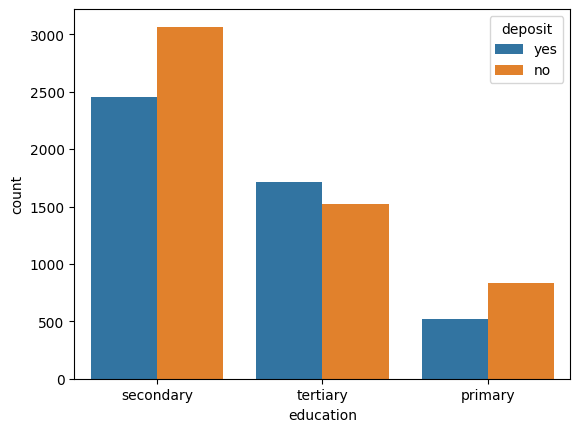

In [23]:
# постройте визуализации для открывших и неоткрывших депозит в зависимости от образования
sns.countplot(x='education', data=df,hue='deposit')

<Axes: xlabel='deposit', ylabel='count'>

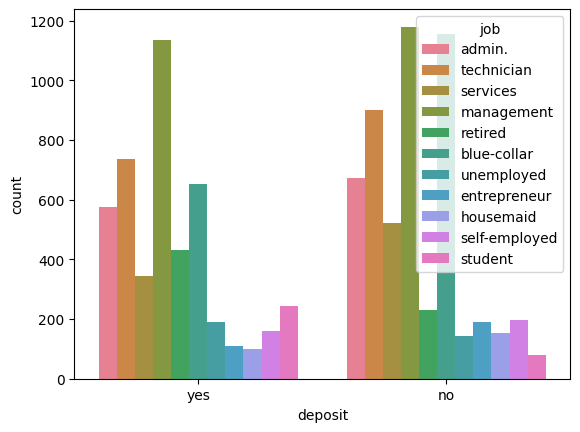

In [24]:
# постройте визуализации для открывших и неоткрывших депозит в зависимости от вида профессиональной занятости
sns.countplot(x='deposit', data=df,hue='job')


### Задание 11

In [25]:
# постройте сводную таблицу, чтобы определить люди с каким образованием и семейным статусом наиболее многочисленны
#(если рассматривать тех, кто открыл депозит)
mask_true = df[df['deposit']=='yes']
mask_false=df[df['deposit']=='no']
pivot = pd.pivot_table(mask_true, values='deposit',index='job',columns='marital',aggfunc=['count'])
pivot_no=pd.pivot_table(mask_false, values='deposit', index='job', columns='marital', aggfunc=['count'])

<Axes: xlabel='None-marital', ylabel='job'>

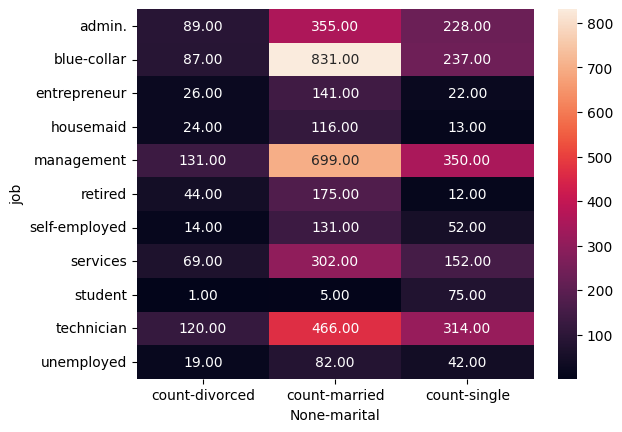

In [26]:
sns.heatmap(pivot_no,
            annot=True, fmt='.2f')

<Axes: xlabel='None-marital', ylabel='job'>

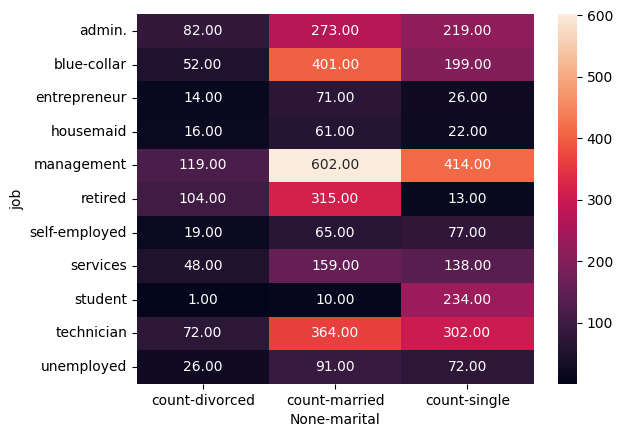

In [27]:
sns.heatmap(pivot,
            annot=True,fmt='.2f')

## Часть 3: преобразование данных

### Задание 1

In [28]:
# преобразуйте уровни образования
df['education'] = LabelEncoder().fit_transform(df['education'])
df['age'] = LabelEncoder().fit_transform(df['age'])

### Задания 2 и 3

In [29]:
# преобразуйте бинарные переменные в представление из нулей и единиц

cols = ['default', 'housing', 'loan', 'deposit']
for col in cols:
    le=LabelEncoder()
    df[f'{col}'] = le.fit_transform(df[col])

In [30]:
df.head()

,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,deposit
0,2,admin.,married,1,0,2343.0,1,0,unknown,5,may,1042,1,-1,0,unknown,1
1,2,admin.,married,1,0,45.0,0,0,unknown,5,may,1467,1,-1,0,unknown,1
2,1,technician,married,1,0,1270.0,1,0,unknown,5,may,1389,1,-1,0,unknown,1
3,2,services,married,1,0,2476.0,1,0,unknown,5,may,579,1,-1,0,unknown,1
4,2,admin.,married,2,0,184.0,0,0,unknown,5,may,673,2,-1,0,unknown,1


In [31]:
df['deposit'].std()

np.float64(0.4986712532452124)

In [32]:
print((df['housing'].mean())+(df['default'].mean())+(df['loan'].mean()))

0.6354280059376547


### Задание 4

In [33]:
# создайте дамми-переменные
cols = ['job','marital','contact','month','poutcome']
df_dum = pd.get_dummies(df, columns=cols, drop_first=False)

In [34]:
df_dum.head()

,age,education,default,balance,housing,loan,day,duration,campaign,pdays,...,month_jun,month_mar,month_may,month_nov,month_oct,month_sep,poutcome_failure,poutcome_other,poutcome_success,poutcome_unknown
0,2,1,0,2343.0,1,0,5,1042,1,-1,...,False,False,True,False,False,False,False,False,False,True
1,2,1,0,45.0,0,0,5,1467,1,-1,...,False,False,True,False,False,False,False,False,False,True
2,1,1,0,1270.0,1,0,5,1389,1,-1,...,False,False,True,False,False,False,False,False,False,True
3,2,1,0,2476.0,1,0,5,579,1,-1,...,False,False,True,False,False,False,False,False,False,True
4,2,2,0,184.0,0,0,5,673,2,-1,...,False,False,True,False,False,False,False,False,False,True


Index(['age', 'job', 'marital', 'education', 'default', 'balance', 'housing',
       'loan', 'contact', 'day', 'month', 'duration', 'campaign', 'pdays',
       'previous', 'poutcome', 'deposit'],
      dtype='object')

### Задания 5 и 6

In [35]:
df_dum['deposit'].unique()

array([1, 0])

<Axes: >

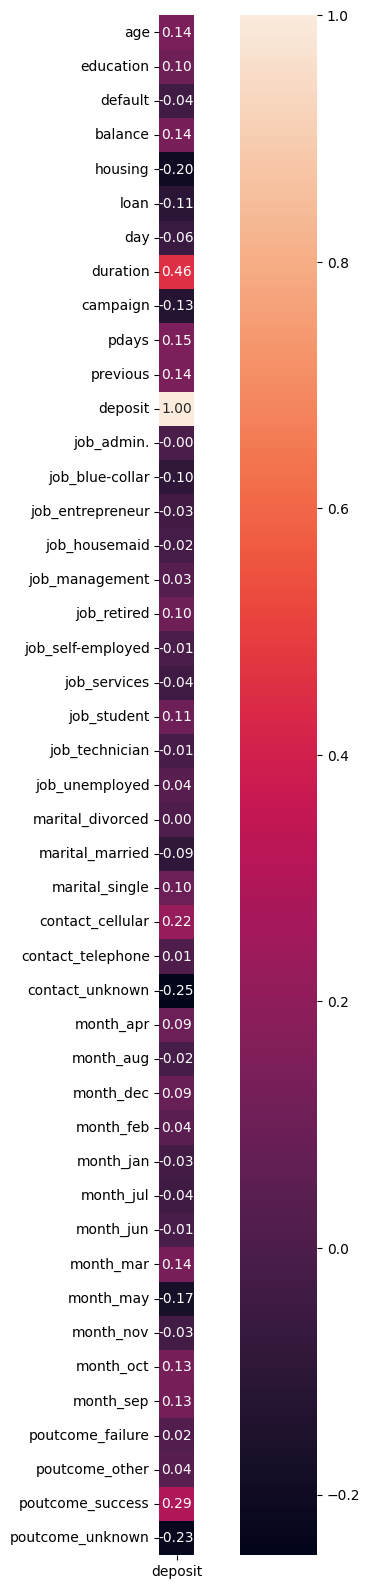

In [36]:
# постройте корреляционную матрицу и оцените данные на предмет наличия мультиколлинеарности
df_corr = df_dum.corr()
plt.figure(figsize=(12,20))
sns.heatmap(
    df_dum.corr()[['deposit']],
    annot=True,
    fmt='.2f',
    square=True
)

### Задания 7 и 8

In [37]:
X = df_dum.drop(['deposit'], axis=1)
y = df_dum['deposit']
 
X_train, X_test, y_train, y_test = train_test_split(X, y, stratify=y, random_state = 42, test_size = 0.33)

In [38]:
# рассчитайте необходимые показатели
y_test.mean()

np.float64(0.46326836581709147)

### Задание 9

In [39]:
# с помощью SelectKBest отберите 15 наиболее подходящих признаков
selecor = SelectKBest(score_func=f_classif,k=15)
selecor.fit(X,y)
best_features=X.columns[selecor.get_support()]
print('top-15: ', best_features.tolist())

top-15:  ['age', 'balance', 'housing', 'duration', 'campaign', 'pdays', 'previous', 'contact_cellular', 'contact_unknown', 'month_mar', 'month_may', 'month_oct', 'month_sep', 'poutcome_success', 'poutcome_unknown']


In [40]:
df_select = X[best_features].copy()
df_select['deposit'] =y

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    df_select.drop('deposit', axis=1),
    df_select['deposit'],
    test_size=0.2,
    random_state=42,
    stratify=df_select['deposit']  
)

### Задание 10

In [61]:
# нормализуйте данные с помощью minmaxsxaler
MMscaler = MinMaxScaler()
X_scaled_train = MMscaler.fit_transform(X_train)
X_scaled_test = MMscaler.transform(X_test)

# Часть 4: Решение задачи классификации: логистическая регрессия и решающие деревья

### Задание 1

In [62]:
# обучите логистическую регрессию и рассчитайте метрики качества
lr = linear_model.LogisticRegression(random_state=42, solver='sag', max_iter=1000, n_jobs=-1)
lr.fit(X_scaled_train, y_train)
print('Train accuracy: {}'.format(lr.score(X_scaled_train, y_train)))
print('Test accuracy: {}'.format(lr.score(X_scaled_test, y_test)))

Train accuracy: 0.8198911429985156
Test accuracy: 0.8124690747154873


### Задания 2,3,4

In [64]:
# обучите решающие деревья, настройте максимальную глубину
dt = tree.DecisionTreeClassifier(random_state=42, criterion='entropy')
dt.fit(X_scaled_train, y_train)
print(f'train accuracy: {dt.score(X_scaled_train,y_train)}')
print(f'Test accuracy: {dt.score(X_scaled_test,y_test)}')

train accuracy: 0.9998762988619495
Test accuracy: 0.7422068283028204


### Задание 5

In [75]:
# подберите оптимальные параметры с помощью gridsearch
param_grid = {'max_depth': [3,5,6,7,10],
              'min_samples_split': [2, 5, 7, 10]}
grid = GridSearchCV(
    estimator=dt,
    param_grid=param_grid,
    scoring='f1',
    cv=5,
    n_jobs=-1
)
grid.fit(X_scaled_train, y_train)
y_pred = grid.predict(X_scaled_test)
print(f'Best params: {grid.best_params_}')
print(f'Best score: {grid.best_score_}')
print(f'Test f1_score: {f1_score(y_test, y_pred)}')
print(f'Train accuracy: {grid.score(X_scaled_train, y_train)}')

Best params: {'max_depth': 7, 'min_samples_split': 7}
Best score: 0.7950190164829893
Test f1_score: 0.8037676609105181
Train accuracy: 0.8204113924050633


# Часть 5: Решение задачи классификации: ансамбли моделей и построение прогноза

### Задание 1

In [77]:
# обучите на ваших данных случайный лес
rf = ensemble.RandomForestClassifier(n_estimators = 100,
criterion = 'gini',
min_samples_leaf = 5,
max_depth = 10,
random_state = 42)
rf.fit(X_scaled_train, y_train)
y_pred = rf.predict(X_scaled_test)
print(f'accuracy: {rf.score(X_scaled_test, y_test)}')
print(f'recall: {metrics.recall_score(y_test, y_pred)}')

accuracy: 0.8312716476991588
recall: 0.8376068376068376


### Задания 2 и 3

In [78]:
# используйте для классификации градиентный бустинг и сравните качество со случайным лесом
gb = ensemble.GradientBoostingClassifier(
    learning_rate = 0.05,
n_estimators = 300,
min_samples_leaf = 5,
max_depth = 5,
random_state = 42
)
gb.fit(X_scaled_train,y_train)
y_pred = gb.predict(X_scaled_test)
print(f'f1_score: {f1_score(y_test,y_pred)}')

f1_score: 0.8162190626645603


### Задание 4

In [ ]:
# объедините уже известные вам алгоритмы с помощью стекинга 
estimators=[
    ('dt',tree.DecisionTreeClassifier(random_state=42, criterion='entropy')),
    ('gb',ensemble.GradientBoostingClassifier(
    learning_rate = 0.05,
    n_estimators = 300,
    min_samples_leaf = 5,
    max_depth = 5,
    random_state = 42)),
    ('lr', linear_model.LogisticRegression(random_state=42, solver='sag', max_iter=1000, n_jobs=-1))]
SR = ensemble.StackingClassifier(
    estimators=estimators,
    final_estimator=linear_model.LogisticRegression(),
    cv=5,
    n_jobs=-1
)
SR.fit(X_scaled_train,y_train)    

,estimators,"[('dt', ...), ('gb', ...), ...]"
,final_estimator,LogisticRegression()
,cv,5
,stack_method,'auto'
,n_jobs,-1
,passthrough,False
,verbose,0
,criterion,'entropy'
,splitter,'best'
,max_depth,None
,min_samples_split,2


In [83]:
y_pred = SR.predict(X_scaled_test)
print(f'presicion: {metrics.precision_score(y_test,y_pred)}')

presicion: 0.81445523193096


### Задание 5

In [87]:
# оцените, какие признаки демонстрируют наибольшую  важность в модели градиентного бустинга
important_cols = gb.feature_importances_
print(important_cols)
print(list(X_scaled_train.columns))

[0.04260628 0.05816701 0.04721193 0.50272763 0.01640198 0.0512663
 0.01426661 0.00370438 0.07710833 0.0285291  0.01288863 0.02136883
 0.01166603 0.11071272 0.00137424]


AttributeError: 'numpy.ndarray' object has no attribute 'columns'

In [89]:
feature_names = X_train.columns.tolist() 
importance_df = pd.DataFrame({
    'feature': feature_names,
    'importance': gb.feature_importances_
}).sort_values('importance', ascending=False)
importance_df

,feature,importance
3,duration,0.502728
13,poutcome_success,0.110713
8,contact_unknown,0.077108
1,balance,0.058167
5,pdays,0.051266
2,housing,0.047212
0,age,0.042606
9,month_mar,0.028529
11,month_oct,0.021369
4,campaign,0.016402


### Задания 6,7,8

In [90]:
# реализуйте оптимизацию гиперпараметров с помощью Optuna
import optuna

In [94]:
def optuna_trail(trial):
    params = {'n_estimators': trial.suggest_int('n_estimators', 100, 200, 1),
               'max_depth': trial.suggest_int('max_depth', 10, 30, 1),
               'min_samples_leaf': trial.suggest_int('min_samples_leaf', 2, 10, 1)}
    rf = ensemble.RandomForestClassifier(**params, random_state=42, n_jobs=-1)
    rf.fit(X_scaled_train,y_train)
    y_pred = rf.predict(X_scaled_test)
    return metrics.accuracy_score(y_test,y_pred)
study = optuna.create_study(direction='maximize')
study.optimize(optuna_trail, n_trials=50)

print('f1_score: {}'.format(study.best_value))

[I 2025-12-19 19:22:15,988] A new study created in memory with name: no-name-e8aa4a97-8791-433b-b23b-a338db156959
[I 2025-12-19 19:22:16,513] Trial 0 finished with value: 0.8283028203859476 and parameters: {'n_estimators': 116, 'max_depth': 27, 'min_samples_leaf': 2}. Best is trial 0 with value: 0.8283028203859476.
[I 2025-12-19 19:22:16,908] Trial 1 finished with value: 0.8327560613557645 and parameters: {'n_estimators': 114, 'max_depth': 10, 'min_samples_leaf': 3}. Best is trial 1 with value: 0.8327560613557645.
[I 2025-12-19 19:22:17,378] Trial 2 finished with value: 0.830776843146957 and parameters: {'n_estimators': 138, 'max_depth': 26, 'min_samples_leaf': 4}. Best is trial 1 with value: 0.8327560613557645.
[I 2025-12-19 19:22:17,874] Trial 3 finished with value: 0.8287976249381495 and parameters: {'n_estimators': 144, 'max_depth': 24, 'min_samples_leaf': 5}. Best is trial 1 with value: 0.8327560613557645.
[I 2025-12-19 19:22:18,456] Trial 4 finished with value: 0.8243443839683325

f1_score: 0.8342404750123701
